# **FINITE ELEMENT MODELING OF A PLANAR PIN-JOINTED TRUSS**

We will examine how to transition from the theory of the finite element method to a computational model of a plane truss. As a basis, we will use the classical formulation for a plane pin-jointed truss from the book An Introduction to Finite Element Analysis by D. H. Norrie and G. de Vries.


# 1. Theoretical Part


## 1.1 Truss as an Assembly of Finite Elements

A plane pin-jointed truss belongs to **discrete systems**: 
it consists of individual members connected at nodes

This makes it a convenient subject for introducing the finite element method, because:

- the structure is already naturally divided into elements;
- interaction between elements occurs through nodes;
- loads and constraints are conveniently applied directly at the nodes;
- the entire problem reduces to formulating and solving a system of linear algebraic equations.\

The idea of the method here is very simple:

- each **bulk** contributes to the stiffness of the structure;
- then the contributions of all bulks are **assembled** into a global matrix;
- after that, the unknown nodal displacements and support reactions are determined..

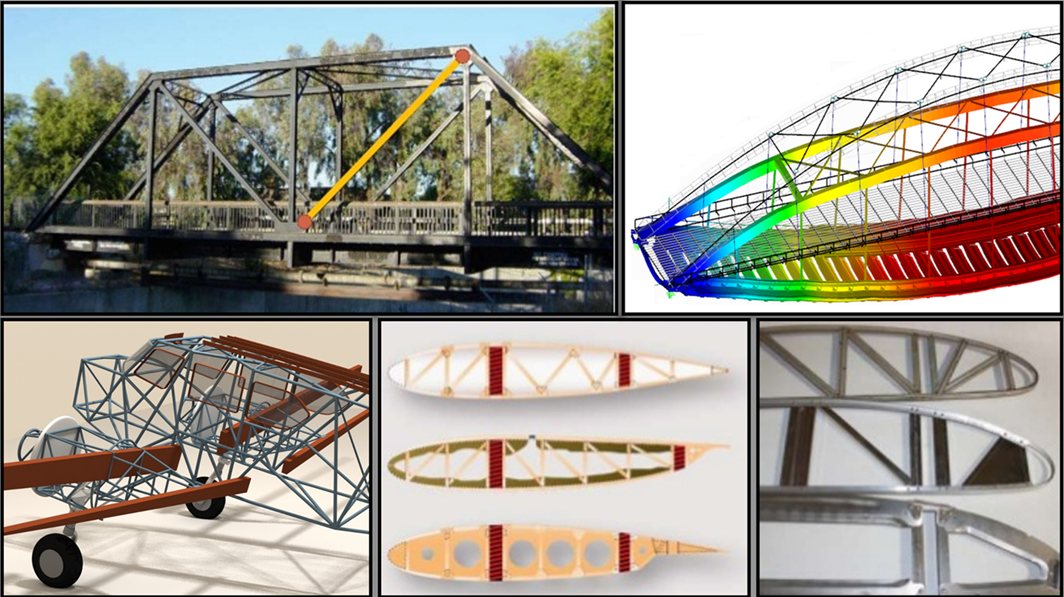

### Main Model Assumptions

We consider a **plane pin-jointed truss** and make the following assumptions:

1. Bulks are connected to each other by ideal pins.
2. Loads are applied only at **nodes**.
3. Each bulk works only in:
   - **tension**,
   - **compression**.
4. Bending, shear forces, and moments in members are neglected.
5. The model obeys Hooke's law.
6. Displacements are assumed to be small.

Under these assumptions, each member can be treated as **a two-node finite element**

## 1.2 A Single Bar as a Finite Element

Consider a single bar connecting two nodes: $i$ and $j$.

Let:
- the bar length be $L$;
- the cross-sectional area be $A$;
- Young’s modulus be $E$;
- the angle of inclination of the bar with respect to the $x$-axis be $\theta$.

Define the direction cosines as:

$$
c = \cos\theta, \qquad s = \sin\theta
$$

In a 2D problem, each node has two degrees of freedom:
- displacement along the $x$-axis,
- displacement along the $y$-axis.

Therefore, the element nodal displacement vector has the form:

$$
\mathbf{u}^{(e)} =
\begin{bmatrix}
u_{xi} \\
u_{yi} \\
u_{xj} \\
u_{yj}
\end{bmatrix}
$$

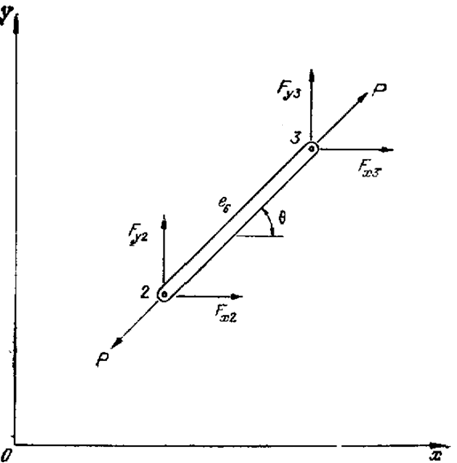

### Elongation of a Bar in Terms of Nodal Displacements

The axial deformation of a bar is determined by projecting the relative displacement of its ends onto the bar axis.

The elongation of the element is:

$$
\Delta L =
(u_{xj} - u_{xi})\cos\theta + (u_{yj} - u_{yi})\sin\theta
$$

or, using the notation $c=\cos\theta$, $s=\sin\theta$:

$$
\Delta L = (u_{xj} - u_{xi})c + (u_{yj} - u_{yi})s
$$

Then the axial strain is:

$$
\varepsilon = \frac{\Delta L}{L}
$$

This is the key relationship between the **geometry of the element** and the **nodal displacements**.

### Axial Force in a Bar

According to Hooke’s law:

$$
\sigma = E \varepsilon
$$

Then the axial force in the bar is:

$$
P = \sigma A = EA \varepsilon
$$

Substituting the expression for the strain, we obtain:

$$
P = \frac{EA}{L}
\left[
(u_{xj} - u_{xi})c + (u_{yj} - u_{yi})s
\right]
$$

Thus, the axial force is completely determined by:

- the stiffness characteristics of the element, $E$ and $A$,
- its length, $L$,
- its position in the plane through $c$ and $s$,
- the nodal displacements.

### Element Nodal Force Vector

The axial force $P$ acts along the bar axis.  
Its projections onto the global axes give the element nodal forces.

The nodal force vector in the global coordinate system is:

$$
\mathbf{F}^{(e)} =
\begin{bmatrix}
F_{xi}^{(e)} \\
F_{yi}^{(e)} \\
F_{xj}^{(e)} \\
F_{yj}^{(e)}
\end{bmatrix}
=
\begin{bmatrix}
- Pc \\
- Ps \\
Pc \\
Ps
\end{bmatrix}
$$

The minus sign at the first node and the plus sign at the second node reflect the fact that the internal forces at the ends of the element are equal in magnitude and opposite in direction.

### Stiffness Matrix of a Bar Element

Substituting the expression for the axial force $P$ into the formula for the nodal force vector, we obtain:

$$
\mathbf{F}^{(e)} = \mathbf{k}^{(e)} \mathbf{u}^{(e)}
$$

where the element stiffness matrix in global coordinates has the form:

$$
\mathbf{k}^{(e)} =
\frac{EA}{L}
\begin{bmatrix}
 c^2 & cs  & -c^2 & -cs \\
 cs  & s^2 & -cs  & -s^2 \\
 -c^2 & -cs & c^2 & cs \\
 -cs & -s^2 & cs & s^2
\end{bmatrix}
$$

This is one of the main formulas for a planar truss.

It shows how an individual element relates its nodal forces to its nodal displacements.

### Physical Meaning of the Element Stiffness Matrix

The stiffness matrix $\mathbf{k}^{(e)}$ shows how the element resists deformation.

From the formula, we can see that:

- the factor $\dfrac{EA}{L}$ represents the **axial stiffness of the bar**;
- the coefficients $c$ and $s$ account for the **orientation of the element in the plane**;
- the matrix has size $4 \times 4$ because a two-node element in a 2D problem has four degrees of freedom.

It is important to understand that  
this matrix describes **not the entire truss**, but only **one specific bar element**.

## 1.3 The Truss as a Bar System

A truss consists of several bar elements, and each element contributes to the overall system.

If we denote by $\mathbf{K}$ the stiffness matrix of the entire structure, then it is obtained by summing the contributions of all elements:

$$
\mathbf{K} = \sum_{e=1}^{m} \mathbf{k}^{(e)}
$$

where $m$ is the number of elements.

The idea of assembly is as follows:

1. for each element, its stiffness matrix $\mathbf{k}^{(e)}$ is computed;
2. it is determined which global degrees of freedom correspond to its local nodes;
3. the coefficients of this matrix are added to the appropriate positions of the global matrix $\mathbf{K}$.

This process is called the **assembly of the global stiffness matrix**.

### Global Matrix Equation

After assembling all elements, we obtain the equilibrium equation of the structure:

$$
\mathbf{K}\mathbf{u} = \mathbf{R}
$$

where:

- $\mathbf{K}$ is the global stiffness matrix;
- $\mathbf{u}$ is the vector of all nodal displacements of the structure;
- $\mathbf{R}$ is the vector of external nodal forces.

This is the fundamental finite element equation for our truss.

At this stage, individual bars are no longer treated as separate problems — the entire structure is considered as a single system.

### Boundary Conditions and Support Constraints

Not all displacements in the structure are unknown.

If a node is restrained, then the corresponding displacement components are equal to zero. For example:

- pinned support: $u_x = 0$, $u_y = 0$;
- roller support: only one component is fixed.

Therefore, before solving the system:

1. all degrees of freedom are divided into:
   - **free**,
   - **restrained**;
2. a reduced system for the unknown displacements is extracted from the full system;
3. after finding the displacements, the support reactions are computed.

It is at this stage that the theory connects with its practical implementation in code.

### Truss Analysis Algorithm

The complete solution algorithm can be presented as follows:

1. Define the structural nodes:
   - coordinates,
   - loads,
   - restraints.
2. Define the bar elements:
   - start and end node numbers,
   - $E$ and $A$.
3. For each bar element, compute:
   - the length $L$,
   - $c = \cos\theta$,
   - $s = \sin\theta$,
   - the stiffness matrix $\mathbf{k}^{(e)}$.
4. Assemble the global stiffness matrix $\mathbf{K}$.
5. Assemble the global load vector $\mathbf{R}$.
6. Apply the boundary conditions.
7. Solve for the unknown nodal displacements.
8. Compute the support reactions.
9. For each element, determine:
   - elongation,
   - axial force,
   - stress.

This is exactly the algorithm that we will implement next in Python.

# 2. Solving the Problem for a Simple Example

**Importing the required libraries:**

In [1]:
import numpy as np                                   # library for mathematical operations    
import matplotlib.pyplot as plt                      # library for plotting graphs
from udf_classes_test import Node, Bar, Truss        # custom file with class definitions for the problem  - for third part of the lession

Our goal is to demonstrate how to:

- define the geometry of the structure;
- describe the nodes and bar elements;
- form the element stiffness matrices;
- assemble the global system;
- find the nodal displacements, support reactions, and axial forces in the bars.

We will follow the classical example of analyzing a simple pin-jointed truss.

### Problem Statement

It is required to compute the displacements of node 2 for a pin-jointed truss.

Given:

- each bar has length $L = 10$ cm;
- cross-sectional area:
  $$
  A = 1 \text{ cm}^2
  $$
- Young’s modulus:
  $$
  E = 2 \cdot 10^6 \text{ kgf/cm}^2
  $$

An external force of magnitude $1000$ kgf is applied at node 2 at an angle of $60^\circ$.

It is also required to determine the support reactions at nodes 1 and 3.

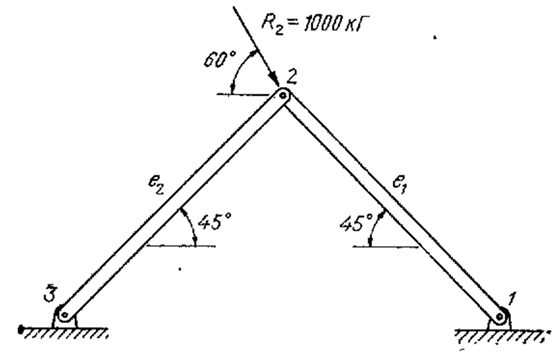

**Geometric Properties of the Bars:**

In [2]:
Et = 2e6                  # Young's modulus, Pa
At = 1                    # Bar cross-sectional area, m²
L = 1                     # Bar length, m
Fld = 1000                # Force, N

### Structural Scheme

The structure consists of three nodes:

- node **1** — the right support;
- node **2** — the upper node, where the load is applied;
- node **3** — the left support.

Bar elements:

- element $e_1$ connects nodes **2** and **1**;
- element $e_2$ connects nodes **3** and **2**.

Both bars are inclined at an angle of $45^\circ$ to the horizontal.e horizontal.

### Choice of Node Coordinates

For the programmatic implementation, it is convenient to define the node coordinates in a Cartesian coordinate system.

$$
(x_1, y_1) = \left(2L\cos45^\circ,\ 0\right)
$$

$$
(x_2, y_2) = \left(L\cos45^\circ,\ L\sin45^\circ\right)
$$

$$
(x_3, y_3) = (0, 0)
$$

In [3]:
nn = 3
nodes = np.zeros([nn,2])
nodes[0,:] = 2*L*np.cos(45*(np.pi / 180)), 0
nodes[1,:] = L*np.cos(45*(np.pi / 180)), L*np.sin(45*(np.pi / 180))
nodes[2,:] = 0, 0
nodes

array([[1.41421356, 0.        ],
       [0.70710678, 0.70710678],
       [0.        , 0.        ]])

### Degrees of Freedom of the System

In a 2D problem, each node has two degrees of freedom:

- displacement along the $x$-axis;
- displacement along the $y$-axis.

Therefore, the full displacement vector of the system can be written as:

$$
\mathbf{u} =
\begin{bmatrix}
u_{x1} \\
u_{y1} \\
u_{x2} \\
u_{y2} \\
u_{x3} \\
u_{y3}
\end{bmatrix}
$$

In this example, nodes 1 and 3 are restrained, therefore:

$$
u_{x1} = 0,\quad u_{y1} = 0,\quad u_{x3} = 0,\quad u_{y3} = 0
$$

The only unknowns are:

$$
u_{x2},\quad u_{y2}
$$

In [4]:
# Define the support conditions
supp = np.zeros([nn,2])
supp[0,:] = 1, 1
supp[1,:] = 0, 0
supp[2,:] = 1, 1
supp

array([[1., 1.],
       [0., 0.],
       [1., 1.]])

### Decomposition of the External Force into Components

A force of magnitude $1000$ kgf is applied at node 2 at an angle of $60^\circ$.

Let us decompose it into components along the global axes:

$$
F_{x2} = 1000 \cos 60^\circ = 500
$$

$$
F_{y2} = -1000 \sin 60^\circ \approx -866
$$

The minus sign of the vertical component means that the force is directed downward.

Therefore, the external load vector of the system has the form:

$$
\mathbf{F} =
\begin{bmatrix}
0 \\
0 \\
500 \\
-866 \\
0 \\
0
\end{bmatrix}
$$

In [5]:
Fload = np.zeros([nn,2])
Fload[1, :] = Fld*np.sin(30*(np.pi / 180)), -Fld*np.cos(30*(np.pi / 180))
Fload

array([[   0.        ,    0.        ],
       [ 500.        , -866.02540378],
       [   0.        ,    0.        ]])

### Element $e_1$: Bar Between Nodes 2 and 1

For the right bar, the angle of inclination is $-45^\circ$.

Therefore, the direction cosines are:

$$
c = \cos(-45^\circ) = \frac{\sqrt{2}}{2}, \qquad
s = \sin(-45^\circ) = -\frac{\sqrt{2}}{2}
$$

Substituting these values into the general formula, we obtain the stiffness matrix of element $e_1$.

At this stage, it is especially important to check:

- the sign of $c$,
- the sign of $s$,
- the symmetry of the matrix,
- the correctness of the signs of the off-diagonal terms.

### Element $e_2$: Bar Between Nodes 3 and 2

For the left bar, the angle of inclination is $45^\circ$, therefore:

$$
c = \cos 45^\circ = \frac{\sqrt{2}}{2}, \qquad
s = \sin 45^\circ = \frac{\sqrt{2}}{2}
$$

After substituting these values into the stiffness matrix formula, we obtain the matrix of element $e_2$.

Although both elements have the same values of $E$, $A$, and $L$, their contribution to the global system differs because of the different node numbering and their position in the structure.

In [6]:
ne = 2
elms = np.zeros([ne, 2], dtype=int)
elms[0,:] = 1.0, 2.0
elms[1,:] = 2.0, 3.0
elms

array([[1, 2],
       [2, 3]])

Based on these values, the element stiffness matrix is determined as:

$$
\mathbf{k}^{(e)} =
\frac{EA}{L}
\begin{bmatrix}
 c^2 & cs  & -c^2 & -cs \\
 cs  & s^2 & -cs  & -s^2 \\
 -c^2 & -cs & c^2 & cs \\
 -cs & -s^2 & cs & s^2
\end{bmatrix}
$$

In [7]:
Klocls = []
for el in range(ne):
    nd1, nd2 = elms[el,:]
    x1, y1 = nodes[nd1-1, :]
    x2, y2 = nodes[nd2-1, :] 
    dx = x2 - x1
    dy = y2 - y1
    len = (dx**2 + dy**2) ** 0.5
    c = dx / len
    s = dy / len
    Klocls.append(Et*At/ len * np.array([
            [ c*c,  c*s, -c*c, -c*s],
            [ c*s,  s*s, -c*s, -s*s],
            [-c*c, -c*s,  c*c,  c*s],
            [-c*s, -s*s,  c*s,  s*s]  ]))

In [8]:
Klocls

[array([[ 1000000., -1000000., -1000000.,  1000000.],
        [-1000000.,  1000000.,  1000000., -1000000.],
        [-1000000.,  1000000.,  1000000., -1000000.],
        [ 1000000., -1000000., -1000000.,  1000000.]]),
 array([[ 1000000.,  1000000., -1000000., -1000000.],
        [ 1000000.,  1000000., -1000000., -1000000.],
        [-1000000., -1000000.,  1000000.,  1000000.],
        [-1000000., -1000000.,  1000000.,  1000000.]])]

### Assembly of the Global Stiffness Matrix

After assembling the element contributions, we obtain the global stiffness matrix of the system:

$$
\mathbf{K}
=
10^5
\begin{bmatrix}
1 & -1 & -1 & 1 & 0 & 0 \\
-1 & 1 & 1 & -1 & 0 & 0 \\
-1 & 1 & 2 & 0 & -1 & -1 \\
1 & -1 & 0 & 2 & -1 & -1 \\
0 & 0 & -1 & -1 & 1 & 1 \\
0 & 0 & -1 & -1 & 1 & 1
\end{bmatrix}
$$

This matrix reflects the contribution of both bar elements to the stiffness of the entire truss.

In [9]:
# the global stiffness matrix
Kglob = np.zeros([2*nn, 2*nn])
for el in range(ne):
    nd1, nd2 = elms[el,:]
    ind1 = 2 * (nd1-1), 2 * (nd1-1) + 1
    ind2 = 2 * (nd2-1), 2 * (nd2-1) + 1
    idx = np.array(ind1+ind2, dtype=int)
    Kglob[np.ix_(idx, idx)] += Klocls[el]
Kglob

array([[ 1000000., -1000000., -1000000.,  1000000.,        0.,        0.],
       [-1000000.,  1000000.,  1000000., -1000000.,        0.,        0.],
       [-1000000.,  1000000.,  2000000.,        0., -1000000., -1000000.],
       [ 1000000., -1000000.,        0.,  2000000., -1000000., -1000000.],
       [       0.,        0., -1000000., -1000000.,  1000000.,  1000000.],
       [       0.,        0., -1000000., -1000000.,  1000000.,  1000000.]])

In [10]:
# the global external load vector
Fglob = np.zeros([2*nn, 1])
for nd in range(nn):
    Fglob[2 * nd] = Fload[nd,0]
    Fglob[2 * nd +1] = Fload[nd,1]
Fglob

array([[   0.        ],
       [   0.        ],
       [ 500.        ],
       [-866.02540378],
       [   0.        ],
       [   0.        ]])

### Application of Boundary Conditions

Since nodes 1 and 3 are restrained, we have:

$$
u_{x1} = u_{y1} = u_{x3} = u_{y3} = 0
$$

Therefore, only two components remain unknown:

$$
u_{x2}, \qquad u_{y2}
$$

After eliminating the restrained degrees of freedom, the global system is reduced to a $2 \times 2$ system.

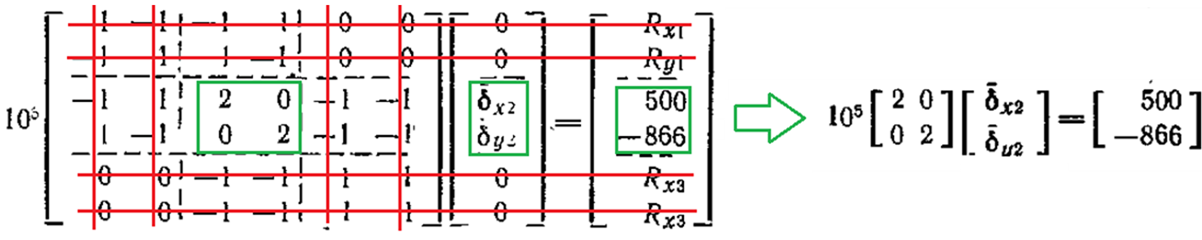

In [11]:
free_dof = []
for nd in range(nn):
    if not supp[nd,0]:
        free_dof.append(2*nd)
    if not supp[nd,1]:
        free_dof.append(2*nd+1)
free_dof

[2, 3]

### Reduced System of Equations

After applying the support constraints, we obtain:

$$
10^5
\begin{bmatrix}
2 & 0 \\
0 & 2
\end{bmatrix}
\begin{bmatrix}
u_{x2} \\
u_{y2}
\end{bmatrix}
=
\begin{bmatrix}
500 \\
-866
\end{bmatrix}
$$

This is already a very simple system from which the displacements of node 2 can be found directly.

In [12]:
Kred=Kglob[np.ix_(free_dof, free_dof)]
Kred

array([[2000000.,       0.],
       [      0., 2000000.]])

In [13]:
Fred=Fglob[free_dof]
Fred

array([[ 500.        ],
       [-866.02540378]])

### Expected Displacements of Node 2

By solving the reduced system, we obtain:

$$
u_{x2} = \frac{500}{2 \cdot 10^5} = 2.5 \cdot 10^{-3} \text{ cm}
$$

$$
u_{y2} = \frac{-866}{2 \cdot 10^5} = -4.33 \cdot 10^{-3} \text{ cm}
$$

This means that:

- node 2 moves slightly to the right;
- node 2 moves downward.

Such a result is physically natural for the applied force.

In [14]:
u = np.zeros([2*nn,1])
u[free_dof] = np.linalg.solve(Kred, Fred)
u

array([[ 0.        ],
       [ 0.        ],
       [ 0.00025   ],
       [-0.00043301],
       [ 0.        ],
       [ 0.        ]])

### Support Reactions

After substituting the computed displacements into the full system, we obtain the support reactions:

$$
R_{x1} = -683 \text{ kgf}
$$

$$
R_{y1} = 683 \text{ kgf}
$$

$$
R_{x3} = 183 \text{ kgf}
$$

$$
R_{y3} = 183 \text{ kgf}
$$

These reactions must ensure the equilibrium of the entire structure.ие всей конструкции.

In [15]:
R = Kglob @ u - Fglob
R

array([[-6.83012702e+02],
       [ 6.83012702e+02],
       [-5.68434189e-14],
       [ 0.00000000e+00],
       [ 1.83012702e+02],
       [ 1.83012702e+02]])

### Checking the Equilibrium of the Structure

Let us check the sum of the force components along the $x$-axis:

$$
\sum R_x = -683 + 500 + 183 = 0
$$

Let us check the sum of the force components along the $y$-axis:

$$
\sum R_y = 683 - 866 + 183 = 0
$$

Both checks are satisfied; therefore, the computed reactions are consistent with the equilibrium conditions.

### Plotting the Original and Deformed Structure to Scale

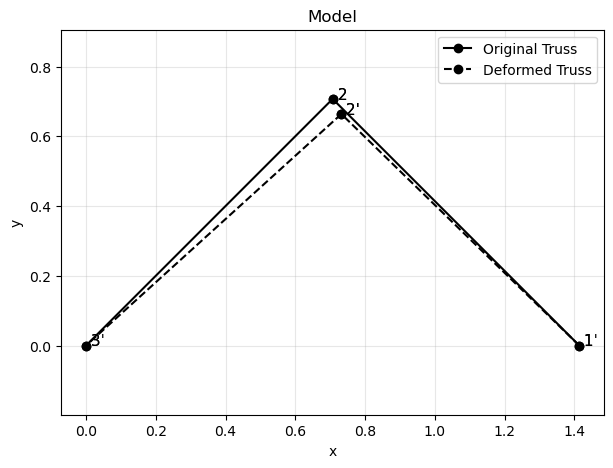

In [16]:
title = "Model"
fig, ax = plt.subplots(figsize=(7, 5))
scale = 100

for el in range(ne):
    nid1, nid2 = elms[el,:]
    x1, y1 = nodes[nid1-1, :]
    x2, y2 = nodes[nid2-1, :] 
    # исходная геометрия
    ax.plot([x1, x2], [y1, y2], "o-", color="black", linewidth=1.5, label="Original Truss"
                if el == 0 else None)
    ax.text(x1, y1, f" {nid1}", fontsize=11)
    ax.text(x2, y2, f" {nid2}", fontsize=11)
    # деформированная геометрия
    dux1, duy1 = u[2 * nid1-2],  u[2 * nid1-1]
    dux2, duy2 = u[2 * nid2-2],  u[2 * nid2-1]
    ax.plot([x1 + scale*dux1, x2 + scale*dux2], [y1 + scale*duy1, y2 + scale*duy2], "o--", color="black", linewidth=1.5, label="Deformed Truss"
            if el == 0 else None)
    ax.text(x1 + scale*dux1, y1 + scale*duy1, f" {nid1}'", fontsize=11)
    ax.text(x2 + scale*dux2, y2 + scale*duy2, f" {nid2}'", fontsize=11)
ax.set_title(title)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# 3. Practical Part (Implementation of Planar Truss Analysis in Python)

## 3.1 Объектная модель плоской фермы

For the programmatic implementation, we introduce three entities:

- `Node` — a structural node;
- `Bar` — a bar element;
- `Truss` — the entire truss as a whole.

### **Node:**

```python
@dataclass
class Node:
    id: int
    x: float
    y: float
    fx: float = 0.0
    fy: float = 0.0
    fix_x: bool = False
    fix_y: bool = False

### **Bar:**

```python
@dataclass
class Bar:
    id: int
    n1: int
    n2: int
    E: float
    A: float

### **Truss**

**Storage of Nodes and Bars**

Inside the `Truss` class, two data structures are used:

- `self.nodes` — a dictionary of nodes;
- `self.bars` — a list of bar elements.

- nodes are conveniently stored in a dictionary by node number so that coordinates, loads, and restraints can be accessed quickly;
- bar elements are conveniently stored in a list because, during assembly, we simply iterate through all elements sequentially.

Methods:

- `add_node(...)` — adds a node to the truss;
- `add_bar(...)` — adds a bar element to the truss.

At this stage, `Truss` acts as a container in which the entire structural model is assembled:

```python
class Truss:
    def __init__(self):
        self.nodes = {}
        self.bars = []

    def add_node(self, node: Node):
        self.nodes[node.id] = node

    def add_bar(self, bar: Bar):
        self.bars.append(bar)
.........................................
```

**Methods `bar_geometry` and `bar_stiffness`**

#### `bar_geometry(bar)`

This method computes the geometry of the selected bar element:

- $\Delta x$
- $\Delta y$
- $L$
- $c$
- $s$

```python
def bar_geometry(self, bar: Bar):
    n1 = self.nodes[bar.n1]
    n2 = self.nodes[bar.n2]
    dx = n2.x - n1.x
    dy = n2.y - n1.y
    L = (dx**2 + dy**2) ** 0.5
    c = dx / L
    s = dy / L
    return dx, dy, L, c, s
```

#### `bar_stiffness(bar)`

After determining the geometry, the element stiffness matrix is constructed:

$$
\mathbf{k}^{(e)} =
\frac{EA}{L}
\begin{bmatrix}
 c^2 & cs  & -c^2 & -cs \\
 cs  & s^2 & -cs  & -s^2 \\
 -c^2 & -cs & c^2 & cs \\
 -cs & -s^2 & cs & s^2
\end{bmatrix}
$$

This is the local contribution of a single bar element to the stiffness of the entire structure.

```python
def bar_stiffness(self, bar: Bar):
    _, _, L, c, s = self.bar_geometry(bar)
    k = bar.E * bar.A / L
    return k * np.array([
        [ c*c,  c*s, -c*c, -c*s],
        [ c*s,  s*s, -c*s, -s*s],
        [-c*c, -c*s,  c*c,  c*s],
        [-c*s, -s*s,  c*s,  s*s]  ])
```

#### Numbering of Nodes and Degrees of Freedom

In a 2D problem, each node has two degrees of freedom:

$$
u_x, \qquad u_y
$$

Therefore, for each node, we need to be able to determine its global indices in the displacement vector and in the global stiffness matrix.

```python
def node_dofs(self, node_id):
    i = node_id -1
    return [2 * i, 2 * i + 1]
```

#### `assemble_K()`

This method creates the global stiffness matrix of the structure.

For each bar element:

- its stiffness matrix is computed;
- the global indices of its degrees of freedom are determined;
- the element matrix is added to the appropriate positions of the global matrix.

```python
def assemble_K(self):
    ndof = 2 * len(self.nodes)
    K = np.zeros((ndof, ndof))
    for bar in self.bars:
        ke = self.bar_stiffness(bar)
        dofs = self.node_dofs(bar.n1) + self.node_dofs(bar.n2)
        K[np.ix_(dofs, dofs)] += ke
    return K
```

#### `assemble_F()`

This method assembles the global load vector.

For each node, the following are included:

- force along $x$;
- force along $y$.

```python
def assemble_F(self):
    ndof = 2 * len(self.nodes)
    F = np.zeros(ndof)

    for nid in self.nodes.keys():
        node = self.nodes[nid]
        ux, uy = self.node_dofs(nid)
        F[ux] = node.fx
        F[uy] = node.fy
    return F
```

#### `get_fixed_free_dofs()`

This method divides all degrees of freedom into two groups:

- `fixed` — restrained;
- `free` — unrestrained.

This prepares the problem for solving the reduced system only for the unknown displacements.

```python
def get_fixed_free_dofs(self):
    fixed = []
    free = []

    for nid in self.nodes.keys():
        node = self.nodes[nid]
        ux, uy = self.node_dofs(nid)

        if node.fix_x:
            fixed.append(ux)
        else:
            free.append(ux)
        if node.fix_y:
            fixed.append(uy)
        else:
            free.append(uy)

    return fixed, free
```

#### Solving the Problem for the Entire Truss

Once the global stiffness matrix and the load vector have been assembled, we can proceed to solve the problem.

The algorithm is as follows:

1. assemble $\mathbf{K}$;
2. assemble $\mathbf{F}$;
3. identify the free degrees of freedom;
4. construct the reduced system:
   $$
   \mathbf{K}_{ff}\mathbf{u}_f = \mathbf{F}_f
   $$
5. solve it;
6. reconstruct the full displacement vector;
7. compute the reactions:
   $$
   \mathbf{R} = \mathbf{K}\mathbf{u} - \mathbf{F}
   $$

```python
def solve(self):
    K = self.assemble_K()
    F = self.assemble_F()
    fixed, free = self.get_fixed_free_dofs()

    K_ff = K[np.ix_(free, free)]
    F_f = F[free]

    u = np.zeros(len(F))
    u[free] = np.linalg.solve(K_ff, F_f)

    R = K @ u - F

    return {
        "K": K,
        "F": F,
        "u": u,
        "R": R,
        "free": free,
        "fixed": fixed,
        "K_ff": K_ff,
        "F_f": F_f,
    }
```

##### `bar_axial_loads(bar, u_global)`

This method computes the axial force and stress in an element.

For this purpose:

1. the displacements of the ends of the given bar are selected;
2. the elongation along the element axis is computed;
3. using the formula
   $$
   N = \frac{EA}{L}\Delta L
   $$
   the axial force is determined.

After the force is found, the stress is computed as:

$$
\sigma = \frac{N}{A}
$$

```python
def bar_axial_loads(self, bar: Bar, u_global):
    _, _, L, c, s = self.bar_geometry(bar)
    dofs = self.node_dofs(bar.n1) + self.node_dofs(bar.n2)
    u_e = u_global[dofs]
    delta_L = np.array([-c, -s, c, s]) @ u_e
    sigma = bar.E / L * delta_L
    force = sigma * bar.A
    return force, sigma

## 3.2 Example of Solving a General Planar Truss Problem

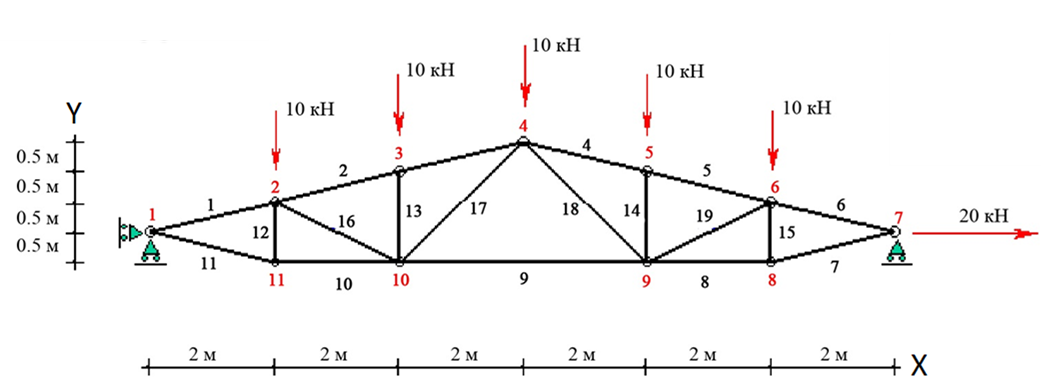

In [17]:
# nodes
nd01 = Node(id=1, x=0,  y=0,    fix_x=True, fix_y=True)
nd02 = Node(id=2, x=2,  y=0.5,  fy=-10000)
nd03 = Node(id=3, x=4,  y=1.0,  fy=-10000)
nd04 = Node(id=4, x=6,  y=1.5,  fy=-10000)
nd05 = Node(id=5, x=8,  y=1.0,  fy=-10000)
nd06 = Node(id=6, x=10, y=0.5,  fy=-10000)
nd07 = Node(id=7, x=12, y=0,    fx=20000, fix_y=True)
nd08 = Node(id=8, x=10, y=-0.5, )
nd09 = Node(id=9, x=8,  y=-0.5, )
nd10 = Node(id=10, x=4,  y=-0.5,)
nd11 = Node(id=11, x=2,  y=-0.5,)
nds = [nd01, nd02, nd03, nd04, nd05, nd06, nd07, nd08, nd09, nd10, nd11]

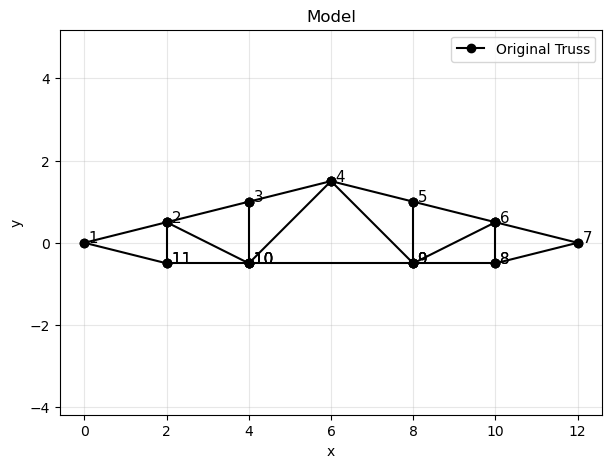

In [18]:
truss = Truss()
E=2e11
# collect nodes
for nd in nds:
    truss.add_node(nd) 
# collect bars
truss.add_bar(Bar(id=1,  n1=1,  n2=2,  E=E, A=8))
truss.add_bar(Bar(id=2,  n1=2,  n2=3,  E=E, A=8))
truss.add_bar(Bar(id=3,  n1=3,  n2=4,  E=E, A=8))
truss.add_bar(Bar(id=4,  n1=4,  n2=5,  E=E, A=8))
truss.add_bar(Bar(id=5,  n1=5,  n2=6,  E=E, A=8))
truss.add_bar(Bar(id=6,  n1=6,  n2=7,  E=E, A=8))
truss.add_bar(Bar(id=7,  n1=7,  n2=8,  E=E, A=6))
truss.add_bar(Bar(id=8,  n1=8,  n2=9,  E=E, A=6))
truss.add_bar(Bar(id=9,  n1=9,  n2=10, E=E, A=6))
truss.add_bar(Bar(id=10, n1=10, n2=11, E=E, A=6))
truss.add_bar(Bar(id=11, n1=11, n2=1,  E=E, A=6))
truss.add_bar(Bar(id=12, n1=11, n2=2,  E=E, A=4))
truss.add_bar(Bar(id=13, n1=10, n2=3,  E=E, A=4))
truss.add_bar(Bar(id=14, n1=9,  n2=5,  E=E, A=4))
truss.add_bar(Bar(id=15, n1=8,  n2=6,  E=E, A=4))
truss.add_bar(Bar(id=16, n1=10, n2=2,  E=E, A=4))
truss.add_bar(Bar(id=17, n1=10, n2=4,  E=E, A=4))
truss.add_bar(Bar(id=18, n1=9,  n2=4,  E=E, A=4))
truss.add_bar(Bar(id=19, n1=9,  n2=6,  E=E, A=4))
truss.plot_frame()

In [19]:
result = truss.solve()
u = result["u"]
R = result["R"]
u

array([ 0.00000000e+00,  0.00000000e+00,  1.47361165e-07, -8.08484648e-07,
        1.67445607e-07, -1.14436907e-06,  1.12086331e-07, -1.17847861e-06,
        5.67270556e-08, -1.14436907e-06,  7.68114973e-08, -8.08484648e-07,
        2.24172663e-07,  0.00000000e+00,  3.12086331e-07, -7.89734648e-07,
        2.12086331e-07, -1.12561907e-06,  1.20863313e-08, -1.12561907e-06,
       -8.79136687e-08, -7.89734648e-07])

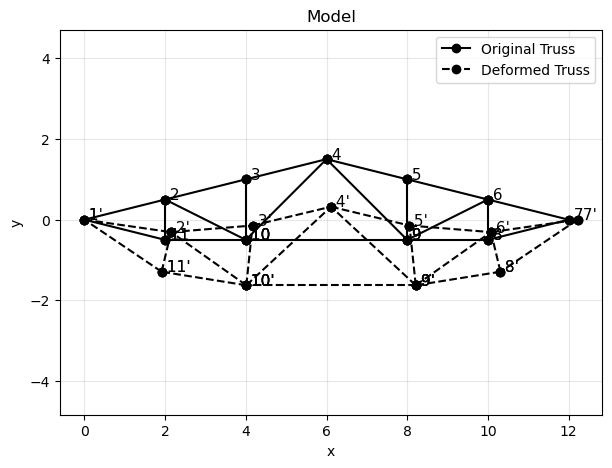

In [20]:
truss.plot_frame(u, scale=1000000)